In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

In [ ]:
TRAIN_DIR = "/content/drive/MyDrive/datasets/train"
TEST_DIR = "/content/drive/MyDrive/datasets/test"

BATCH_SIZE=64

In [ ]:
def train_val_generators(TRAINING_DIR, TEST_DIR):

  train_datagen = ImageDataGenerator(rescale= 1.0/255.0,
                                     rotation_range= 45,
                                     width_shift_range= 0.2,
                                     height_shift_range= 0.2,
                                     shear_range= 0.2,
                                     zoom_range= 0.2,
                                     horizontal_flip= True,
                                     fill_mode= 'nearest')


  train_generator = train_datagen.flow_from_directory(directory= TRAINING_DIR,
                                                      batch_size= 20,
                                                      class_mode= 'categorical',
                                                      target_size=(224, 224))


  test_datagen = ImageDataGenerator( rescale = 1.0/255.0 )


  test_generator = test_datagen.flow_from_directory(directory= TEST_DIR,
                                                                batch_size= 20,
                                                                class_mode= 'categorical',
                                                                target_size=(224, 224))

  return train_generator, test_generator

In [ ]:
train_generator, test_generator = train_val_generators(TRAIN_DIR, TEST_DIR)

Found 5757 images belonging to 21 classes.
Found 1640 images belonging to 21 classes.


In [ ]:
label_map = train_generator.class_indices
print(label_map)

{'Grape__black_measles': 0, 'Grape__black_rot': 1, 'Grape__healthy': 2, 'Grape__leaf_blight_(isariopsis_leaf_spot)': 3, 'Lemon__diseased': 4, 'Lemon__healthy': 5, 'Pomegranate__diseased': 6, 'Pomegranate__healthy': 7, 'guava_Disease Free': 8, 'guava_Phytopthora': 9, 'guava_Red rust': 10, 'guava_Scab': 11, 'guava_Styler and Root': 12, 'mango_Anthracnose': 13, 'mango_Bacterial Canker': 14, 'mango_Cutting Weevil': 15, 'mango_Die Back': 16, 'mango_Gall Midge': 17, 'mango_Healthy': 18, 'mango_Powdery Mildew': 19, 'mango_Sooty Mould': 20}


In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(2, 2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dropout(0.5),
    Dense(512, activation='relu'),
    Dense(__builtins__.len(label_map), activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     9,437,696 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 21)             │        10,773 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,689,301 (36.96 MB)

 Trainable params: 9,689,301 (36.96 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from keras.callbacks import ModelCheckpoint, EarlyStopping

In [ ]:
checkpoint = ModelCheckpoint(
    filepath='weights.best.keras',
    monitor='val_loss',
    save_best_only=True
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=10,
    min_delta=0.001
)

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=5,
    steps_per_epoch=__builtins__.len(train_generator),
    validation_steps=__builtins__.len(test_generator),
    callbacks=[checkpoint, early_stopping]
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
288/288 ━━━━━━━━━━━━━━━━━━━━ 3234s 11s/step - accuracy: 0.2440 - loss: 2.4353 - val_accuracy: 0.5518 - val_loss: 1.0559
Epoch 2/5
288/288 ━━━━━━━━━━━━━━━━━━━━ 210s 627ms/step - accuracy: 0.5757 - loss: 1.1915 - val_accuracy: 0.6037 - val_loss: 1.1790
Epoch 3/5
288/288 ━━━━━━━━━━━━━━━━━━━━ 211s 663ms/step - accuracy: 0.7068 - loss: 0.7987 - val_accuracy: 0.6750 - val_loss: 1.0522
Epoch 4/5
288/288 ━━━━━━━━━━━━━━━━━━━━ 187s 648ms/step - accuracy: 0.7809 - loss: 0.6109 - val_accuracy: 0.8256 - val_loss: 0.4975
Epoch 5/5
288/288 ━━━━━━━━━━━━━━━━━━━━ 207s 666ms/step - accuracy: 0.8246 - loss: 0.4987 - val_accuracy: 0.8415 - val_loss: 0.4025


In [ ]:
test_loss, test_acc = model.evaluate(test_generator)
print(f'Test accuracy: {test_acc}')

82/82 ━━━━━━━━━━━━━━━━━━━━ 28s 338ms/step - accuracy: 0.8364 - loss: 0.4034
Test accuracy: 0.8414633870124817


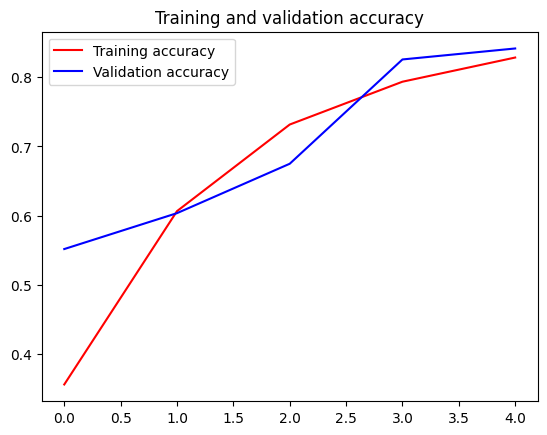

<Figure size 640x480 with 0 Axes>

In [ ]:
import matplotlib.pyplot as plt

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

plt.plot(epochs, acc, 'r', label='Training accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation accuracy')
plt.title('Training and validation accuracy')
plt.legend(loc=0)
plt.figure()

plt.show()

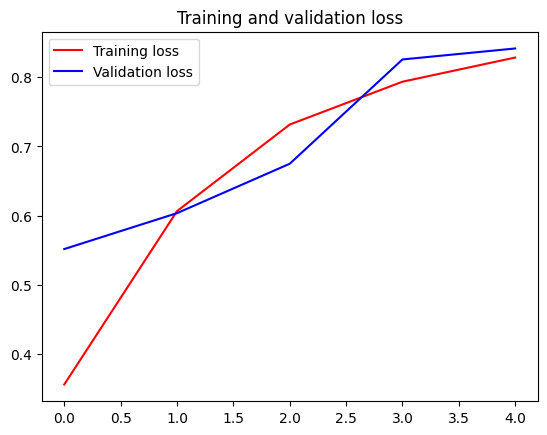

<Figure size 640x480 with 0 Axes>

In [ ]:
plt.plot(epochs, acc, 'r', label='Training loss')
plt.plot(epochs, val_acc, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend(loc=0)
plt.figure()
plt.show()

82/82 ━━━━━━━━━━━━━━━━━━━━ 36s 430ms/step


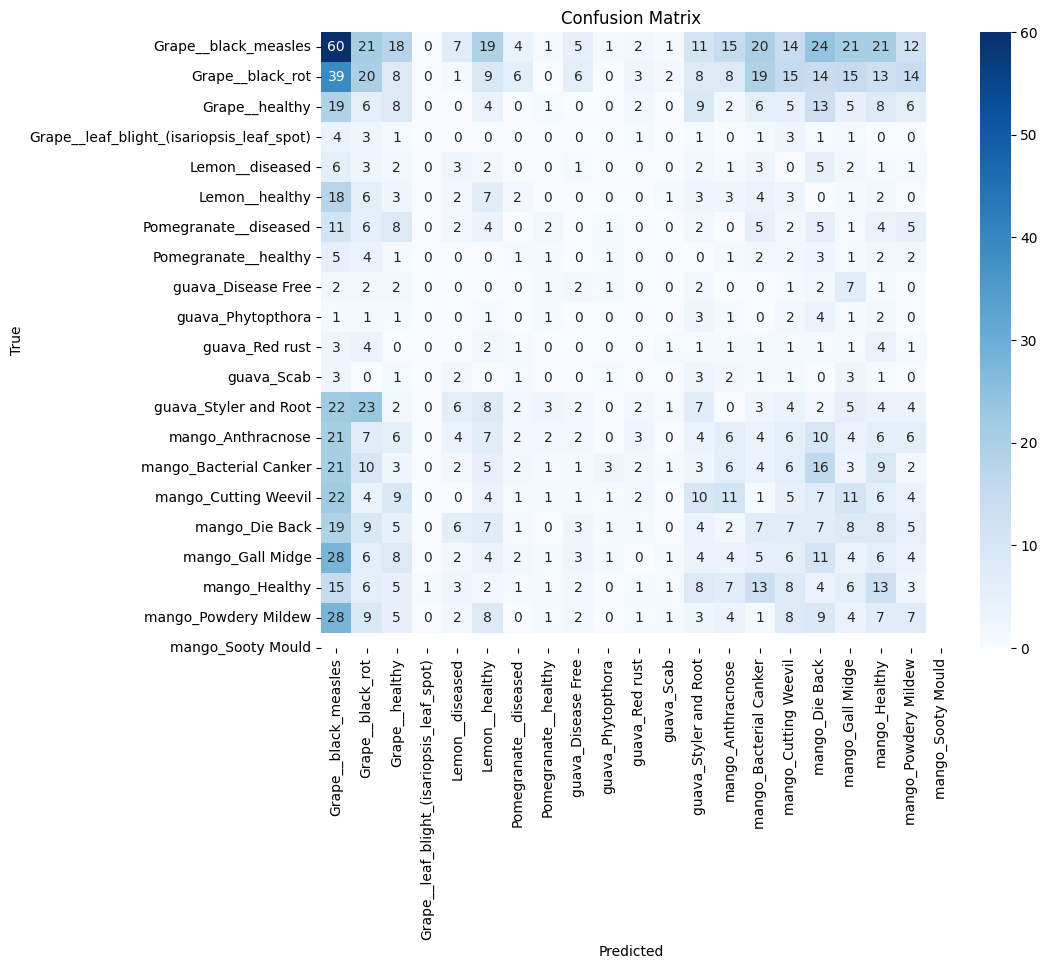

In [ ]:

from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

test_generator.reset()
predictions = model.predict(test_generator, steps=len(test_generator), verbose=1)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes

cm = confusion_matrix(true_classes, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

82/82 ━━━━━━━━━━━━━━━━━━━━ 31s 374ms/step


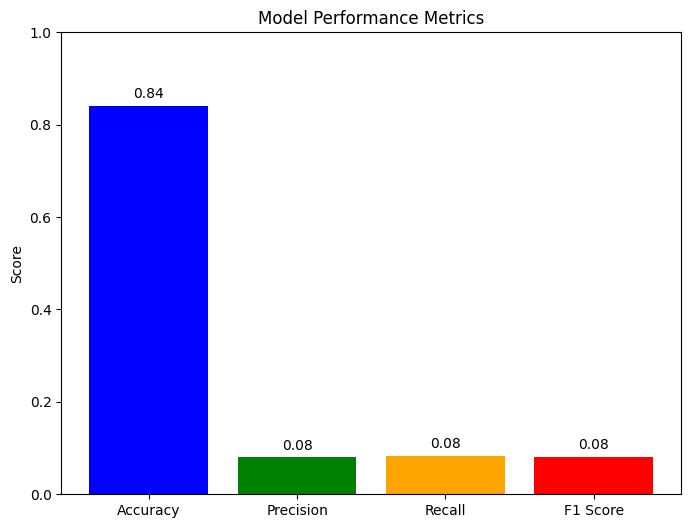

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score, confusion_matrix
test_generator.reset()
y_pred = model.predict(test_generator, steps=len(test_generator), verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

f1 = f1_score(y_true, y_pred_classes, average='weighted')
precision = precision_score(y_true, y_pred_classes, average='weighted')
recall = recall_score(y_true, y_pred_classes, average='weighted')
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [test_acc, precision, recall, f1]

plt.figure(figsize=(8, 6))
plt.bar(metrics, values, color=['blue', 'green', 'orange', 'red'])
plt.ylim(0, 1)
plt.title('Model Performance Metrics')
plt.ylabel('Score')
for i, v in enumerate(values):
    plt.text(i, v + 0.01, f'{v:.2f}', ha='center', va='bottom')
plt.show()